<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/sustax/06_sustax_flood_detection_proxy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Configuración e imports**

In [1]:
from google.colab import drive
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"
SUSTAX_DIR = os.path.join(PROJECT_DIR, "Datos Sustax")

BYSCEN_TOTAL_FOLDER = os.path.join(SUSTAX_DIR, "SUSTAX_TOTAL_MERGED", "BY_SCENARIO_TOTAL")
OUT_DIR = os.path.join(SUSTAX_DIR, "FLOOD_DETECTION_PROXY")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "future_extreme_events_2027_2040.csv")

YEAR_START = 2027
YEAR_END = 2040

POINTS_TO_USE = [
    "Sustax_ Manzanillo_LosReyesTotal",
    "Sustax_ManzanilloTotal",
    "Sustax_MinatitlanTotal",
    "Sustax_TecomanTotal",
    "Sustax_TolimanTotal",
    "Sustax_Veladero_de_OtatesTotal",
    "Sustax_VilladeAlvarezTotal",
    "Sustax_Zapotitlan_de_VadilloTotal",
]

SSP_LIST = ["SSP119", "SSP126", "SSP245", "SSP370", "SSP434", "SSP460", "SSP585"]

print("BYSCEN_TOTAL_FOLDER:", BYSCEN_TOTAL_FOLDER)
print("OUT_DIR:", OUT_DIR)

pd.DataFrame({
    "item": ["BYSCEN_TOTAL_FOLDER", "OUT_DIR", "YEAR_START", "YEAR_END"],
    "value": [BYSCEN_TOTAL_FOLDER, OUT_DIR, YEAR_START, YEAR_END]
}).head()

Mounted at /content/drive
BYSCEN_TOTAL_FOLDER: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_TOTAL_MERGED/BY_SCENARIO_TOTAL
OUT_DIR: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/FLOOD_DETECTION_PROXY


,item,value
0,BYSCEN_TOTAL_FOLDER,/content/drive/MyDrive/Doctorado /Probabilidad...
1,OUT_DIR,/content/drive/MyDrive/Doctorado /Probabilidad...
2,YEAR_START,2027
3,YEAR_END,2040


# **Detección de eventos extremos futuros**

In [2]:
def normalize_date(s):
    d0 = pd.to_datetime(s, errors="coerce", dayfirst=False)
    d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
    dt = d1 if d1.notna().sum() > d0.notna().sum() else d0
    return dt.dt.normalize()

def pick_precip_col(df):
    meta_cols = {"sustax_total", "lat", "lon", "date", "year", "month"}
    candidates = [c for c in df.columns if c not in meta_cols]

    for c in candidates:
        cl = c.lower()
        if ("tp" in cl) and ("precip" in cl):
            return c
    for c in candidates:
        cl = c.lower()
        if ("pr" in cl) and ("precip" in cl):
            return c
    for c in candidates:
        if "precip" in c.lower():
            return c

    if len(candidates) == 1:
        return candidates[0]

    raise ValueError(f"No pude detectar columna de precipitación en {df.columns.tolist()}")

def get_scenario_file(point, scenario):
    pattern = os.path.join(BYSCEN_TOTAL_FOLDER, f"{point}__{scenario}*.csv")
    matches = sorted(glob.glob(pattern))
    return matches[0] if matches else None

events = []

for point in POINTS_TO_USE:
    for scenario in SSP_LIST:

        fp = get_scenario_file(point, scenario)
        if fp is None:
            print(f"⚠️ No encontrado: {point} - {scenario}")
            continue

        df = pd.read_csv(fp)

        if "date" not in df.columns:
            print(f"⚠️ Sin columna date: {fp}")
            continue

        df["date"] = normalize_date(df["date"])
        df = df.dropna(subset=["date"]).copy()

        precip_col = pick_precip_col(df)
        df[precip_col] = pd.to_numeric(df[precip_col], errors="coerce")
        df = df.dropna(subset=[precip_col]).copy()

        df["year"] = df["date"].dt.year
        df["month"] = df["date"].dt.month

        hist = df[df["year"] <= 2014].copy()
        fut = df[(df["year"] >= YEAR_START) & (df["year"] <= YEAR_END)].copy()

        if hist.empty or fut.empty:
            print(f"⚠️ Sin histórico o futuro para: {point} - {scenario}")
            continue

        # 1) Evento diario extremo
        p99_daily = hist[precip_col].quantile(0.99)
        fut_daily_extreme = fut[fut[precip_col] > p99_daily].copy()

        for _, r in fut_daily_extreme.iterrows():
            events.append({
                "point": point,
                "scenario": scenario,
                "date": r["date"],
                "year": int(r["year"]),
                "month": int(r["month"]),
                "event_type": "daily_extreme",
                "value_mm": float(r[precip_col]),
                "threshold_mm": float(p99_daily)
            })

        # 2) Evento semanal extremo
        hist = hist.sort_values("date").copy()
        fut = fut.sort_values("date").copy()

        hist["weekly_7d_mm"] = hist[precip_col].rolling(window=7, min_periods=7).sum()
        fut["weekly_7d_mm"] = fut[precip_col].rolling(window=7, min_periods=7).sum()

        p99_weekly = hist["weekly_7d_mm"].quantile(0.99)
        fut_weekly_extreme = fut[fut["weekly_7d_mm"] > p99_weekly].copy()

        for _, r in fut_weekly_extreme.iterrows():
            events.append({
                "point": point,
                "scenario": scenario,
                "date": r["date"],
                "year": int(r["year"]),
                "month": int(r["month"]),
                "event_type": "weekly_extreme",
                "value_mm": float(r["weekly_7d_mm"]),
                "threshold_mm": float(p99_weekly)
            })

        # 3) Evento mensual extremo
        hist_monthly = (
            hist.groupby(["year", "month"])[precip_col]
            .max()
            .reset_index()
            .rename(columns={precip_col: "monthly_max_mm"})
        )

        fut_monthly = (
            fut.groupby(["year", "month"])[precip_col]
            .max()
            .reset_index()
            .rename(columns={precip_col: "monthly_max_mm"})
        )

        p99_monthly = hist_monthly["monthly_max_mm"].quantile(0.99)
        fut_monthly_extreme = fut_monthly[fut_monthly["monthly_max_mm"] > p99_monthly].copy()

        for _, r in fut_monthly_extreme.iterrows():
            events.append({
                "point": point,
                "scenario": scenario,
                "date": pd.Timestamp(year=int(r["year"]), month=int(r["month"]), day=1),
                "year": int(r["year"]),
                "month": int(r["month"]),
                "event_type": "monthly_extreme",
                "value_mm": float(r["monthly_max_mm"]),
                "threshold_mm": float(p99_monthly)
            })

expected_cols = [
    "point", "scenario", "date", "year", "month",
    "event_type", "value_mm", "threshold_mm"
]

df_future_events = pd.DataFrame(events, columns=expected_cols)

if df_future_events.empty:
    print("⚠️ No se detectaron eventos extremos futuros con el criterio actual.")
else:
    df_future_events = df_future_events.sort_values(
        ["scenario", "event_type", "date"],
        ascending=[True, True, True]
    ).reset_index(drop=True)

display(df_future_events.head(30))

df_future_events.to_csv(OUT_CSV, index=False)

print("Archivo guardado en:")
print(OUT_CSV)

summary = (
    df_future_events
    .groupby(["scenario", "event_type"])
    .size()
    .reset_index(name="n_events")
    .sort_values(["event_type", "n_events"], ascending=[True, False])
)

display(summary.head())

,point,scenario,date,year,month,event_type,value_mm,threshold_mm
0,Sustax_Zapotitlan_de_VadilloTotal,SSP119,2027-02-23,2027,2,daily_extreme,34.332078,26.984014
1,Sustax_MinatitlanTotal,SSP119,2027-09-03,2027,9,daily_extreme,38.258906,32.043510
2,Sustax_Veladero_de_OtatesTotal,SSP119,2027-09-03,2027,9,daily_extreme,44.746693,39.782445
3,Sustax_VilladeAlvarezTotal,SSP119,2027-09-03,2027,9,daily_extreme,43.792121,31.190394
4,Sustax_TecomanTotal,SSP119,2027-09-04,2027,9,daily_extreme,35.309065,33.180650
5,Sustax_TolimanTotal,SSP119,2027-09-08,2027,9,daily_extreme,27.102837,25.722478
6,Sustax_Zapotitlan_de_VadilloTotal,SSP119,2027-09-08,2027,9,daily_extreme,29.469665,26.984014
7,Sustax_TolimanTotal,SSP119,2027-09-09,2027,9,daily_extreme,33.134826,25.722478
8,Sustax_ Manzanillo_LosReyesTotal,SSP119,2027-09-18,2027,9,daily_extreme,64.958230,39.259066
9,Sustax_ManzanilloTotal,SSP119,2027-09-18,2027,9,daily_extreme,66.020347,38.396374


Archivo guardado en:
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/FLOOD_DETECTION_PROXY/future_extreme_events_2027_2040.csv


,scenario,event_type,n_events
18,SSP585,daily_extreme,660
3,SSP126,daily_extreme,572
9,SSP370,daily_extreme,533
6,SSP245,daily_extreme,509
0,SSP119,daily_extreme,483


# **Heatmap por escenario y año**

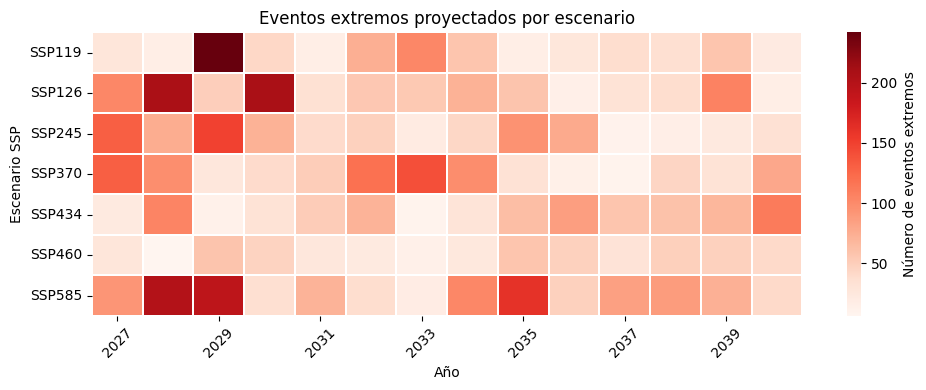

year,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040
scenario,,,,,,,,,,,,,,
SSP119,28,17,242,42,17,74,102,57,17,27,38,36,57,21
SSP126,102,207,50,208,35,55,54,72,58,15,32,38,106,17
SSP245,131,76,149,72,40,48,20,43,95,77,10,16,23,34
SSP370,131,98,26,40,51,119,141,99,33,14,9,44,32,79
SSP434,22,105,12,32,52,71,9,30,63,86,57,60,68,112


In [3]:
timeline = (
    df_future_events.groupby(["scenario", "year"])
    .size()
    .reset_index(name="n_events")
)

heat = timeline.pivot(index="scenario", columns="year", values="n_events")

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    heat,
    cmap="Reds",
    linewidths=0.3,
    annot=False,
    cbar_kws={"label": "Número de eventos extremos"}
)

years = list(heat.columns)
step = 2 if len(years) > 10 else 1
ax.set_xticks(np.arange(0.5, len(years), step))
ax.set_xticklabels(years[::step], rotation=45)

plt.title("Eventos extremos proyectados por escenario")
plt.xlabel("Año")
plt.ylabel("Escenario SSP")
plt.tight_layout()
plt.show()

display(heat.head())

# **Heatmap por tipo de evento y año**

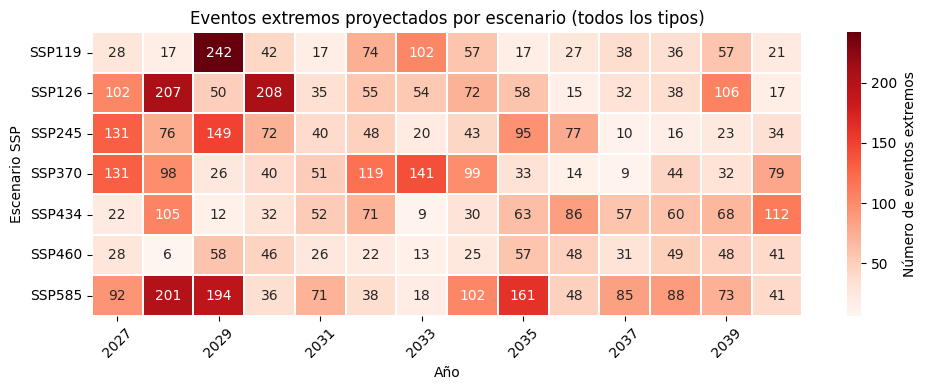

Resumen general:


year,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040
scenario,,,,,,,,,,,,,,
SSP119,28,17,242,42,17,74,102,57,17,27,38,36,57,21
SSP126,102,207,50,208,35,55,54,72,58,15,32,38,106,17
SSP245,131,76,149,72,40,48,20,43,95,77,10,16,23,34
SSP370,131,98,26,40,51,119,141,99,33,14,9,44,32,79
SSP434,22,105,12,32,52,71,9,30,63,86,57,60,68,112


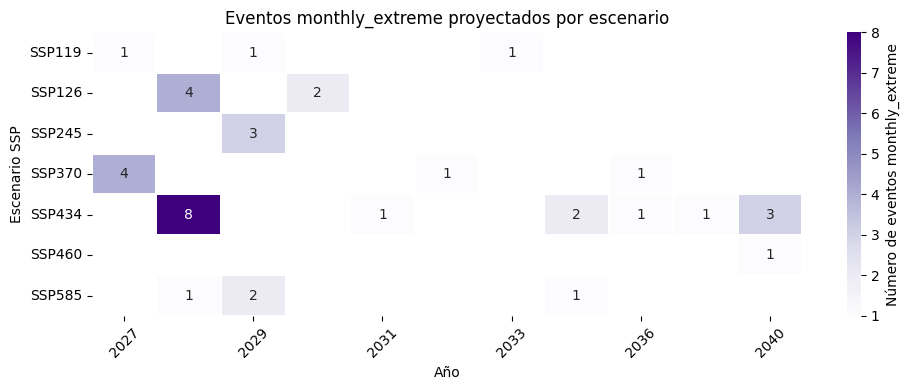

Resumen monthly_extreme:


year,2027,2028,2029,2030,2031,2032,2033,2035,2036,2037,2040
scenario,,,,,,,,,,,
SSP119,1.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
SSP126,NaN,4.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SSP245,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SSP370,4.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN
SSP434,NaN,8.0,NaN,NaN,1.0,NaN,NaN,2.0,1.0,1.0,3.0


year,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040
event_type,,,,,,,,,,,,,,
daily_extreme,290.0,301.0,336.0,281.0,201.0,320.0,220.0,263.0,254.0,217.0,184.0,248.0,261.0,217.0
monthly_extreme,5.0,13.0,6.0,2.0,1.0,1.0,1.0,NaN,3.0,2.0,1.0,NaN,NaN,4.0
weekly_extreme,239.0,396.0,389.0,193.0,90.0,106.0,136.0,165.0,227.0,96.0,77.0,83.0,146.0,124.0


In [7]:

timeline = (
    df_future_events.groupby(["scenario", "year"])
    .size()
    .reset_index(name="n_events")
)

heat = timeline.pivot(index="scenario", columns="year", values="n_events")

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    heat,
    cmap="Reds",
    linewidths=0.3,
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Número de eventos extremos"}
)

years = list(heat.columns)
step = 2 if len(years) > 10 else 1
ax.set_xticks(np.arange(0.5, len(years), step))
ax.set_xticklabels(years[::step], rotation=45)

plt.title("Eventos extremos proyectados por escenario (todos los tipos)")
plt.xlabel("Año")
plt.ylabel("Escenario SSP")
plt.tight_layout()
plt.show()

print("Resumen general:")
display(heat.head())


# -------- Heatmap SOLO monthly_extreme --------
df_monthly_only = df_future_events[df_future_events["event_type"] == "monthly_extreme"].copy()

timeline_monthly = (
    df_monthly_only.groupby(["scenario", "year"])
    .size()
    .reset_index(name="n_events")
)

heat_monthly = timeline_monthly.pivot(index="scenario", columns="year", values="n_events")

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    heat_monthly,
    cmap="Purples",
    linewidths=0.3,
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Número de eventos monthly_extreme"}
)

years = list(heat_monthly.columns)
step = 2 if len(years) > 10 else 1
ax.set_xticks(np.arange(0.5, len(years), step))
ax.set_xticklabels(years[::step], rotation=45)

plt.title("Eventos monthly_extreme proyectados por escenario")
plt.xlabel("Año")
plt.ylabel("Escenario SSP")
plt.tight_layout()
plt.show()

print("Resumen monthly_extreme:")
display(heat_monthly.head())
display(heat_type.head())

# **Eventos por estación**

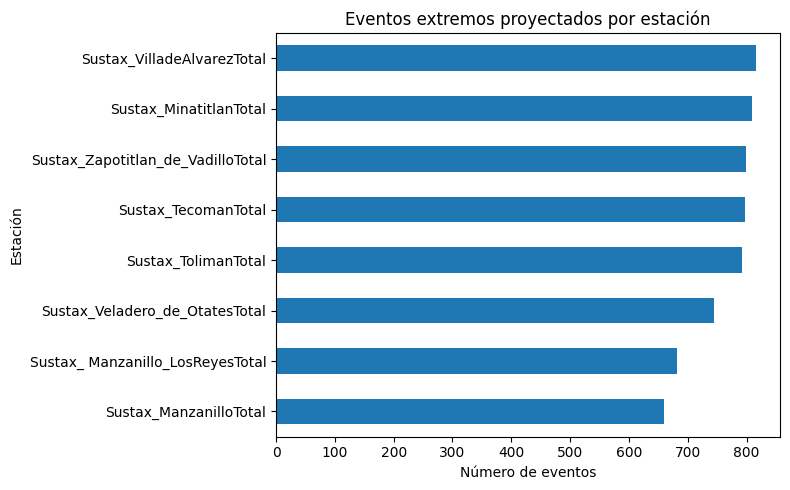

,n_events
point,
Sustax_ManzanilloTotal,659
Sustax_ Manzanillo_LosReyesTotal,681
Sustax_Veladero_de_OtatesTotal,744
Sustax_TolimanTotal,793
Sustax_TecomanTotal,797


In [5]:
station_counts = (
    df_future_events.groupby("point")
    .size()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))
station_counts.plot(kind="barh")

plt.title("Eventos extremos proyectados por estación")
plt.xlabel("Número de eventos")
plt.ylabel("Estación")
plt.tight_layout()
plt.show()

display(station_counts.to_frame("n_events").head())

# **Distribución mensual**

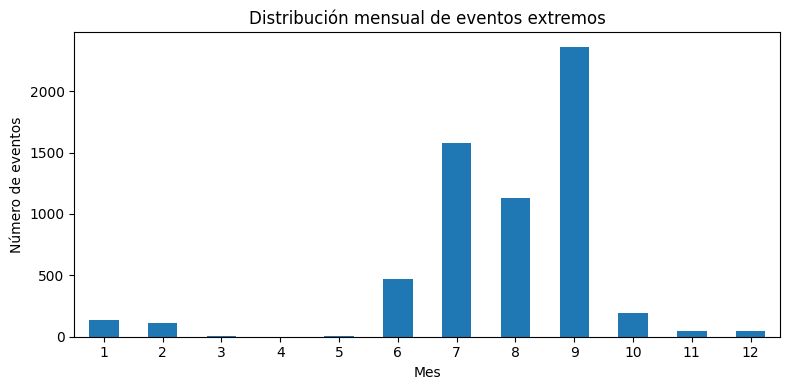

,n_events
month,
1,138
2,114
3,8
4,0
5,8
6,469
7,1576
8,1133
9,2361


In [6]:
month_counts = (
    df_future_events.groupby("month")
    .size()
    .reindex(range(1, 13), fill_value=0)
)

plt.figure(figsize=(8, 4))
month_counts.plot(kind="bar")

plt.title("Distribución mensual de eventos extremos")
plt.xlabel("Mes")
plt.ylabel("Número de eventos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(month_counts.to_frame("n_events").head(12))